
Grid Search finalizado em 112.79s
Campeão Shepard: {'n_neighbors': 200, 'min_dist': 1.0, 'metric': 'cosine', 'spread': 1.5, 'init': 'pca_manual'}
Métricas -> TW: 0.861, CT: 0.869, SH: 0.508


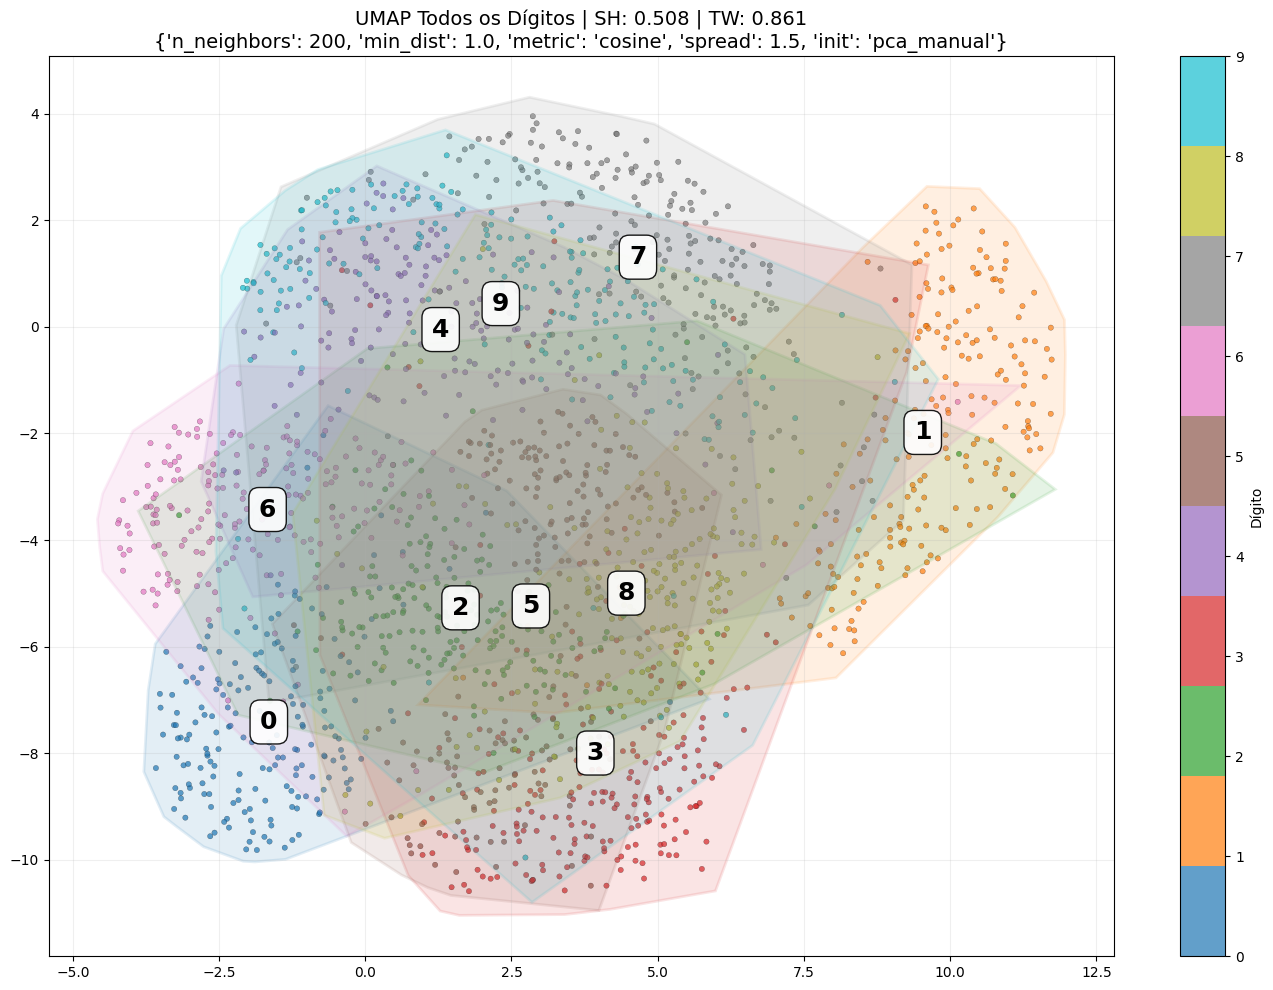

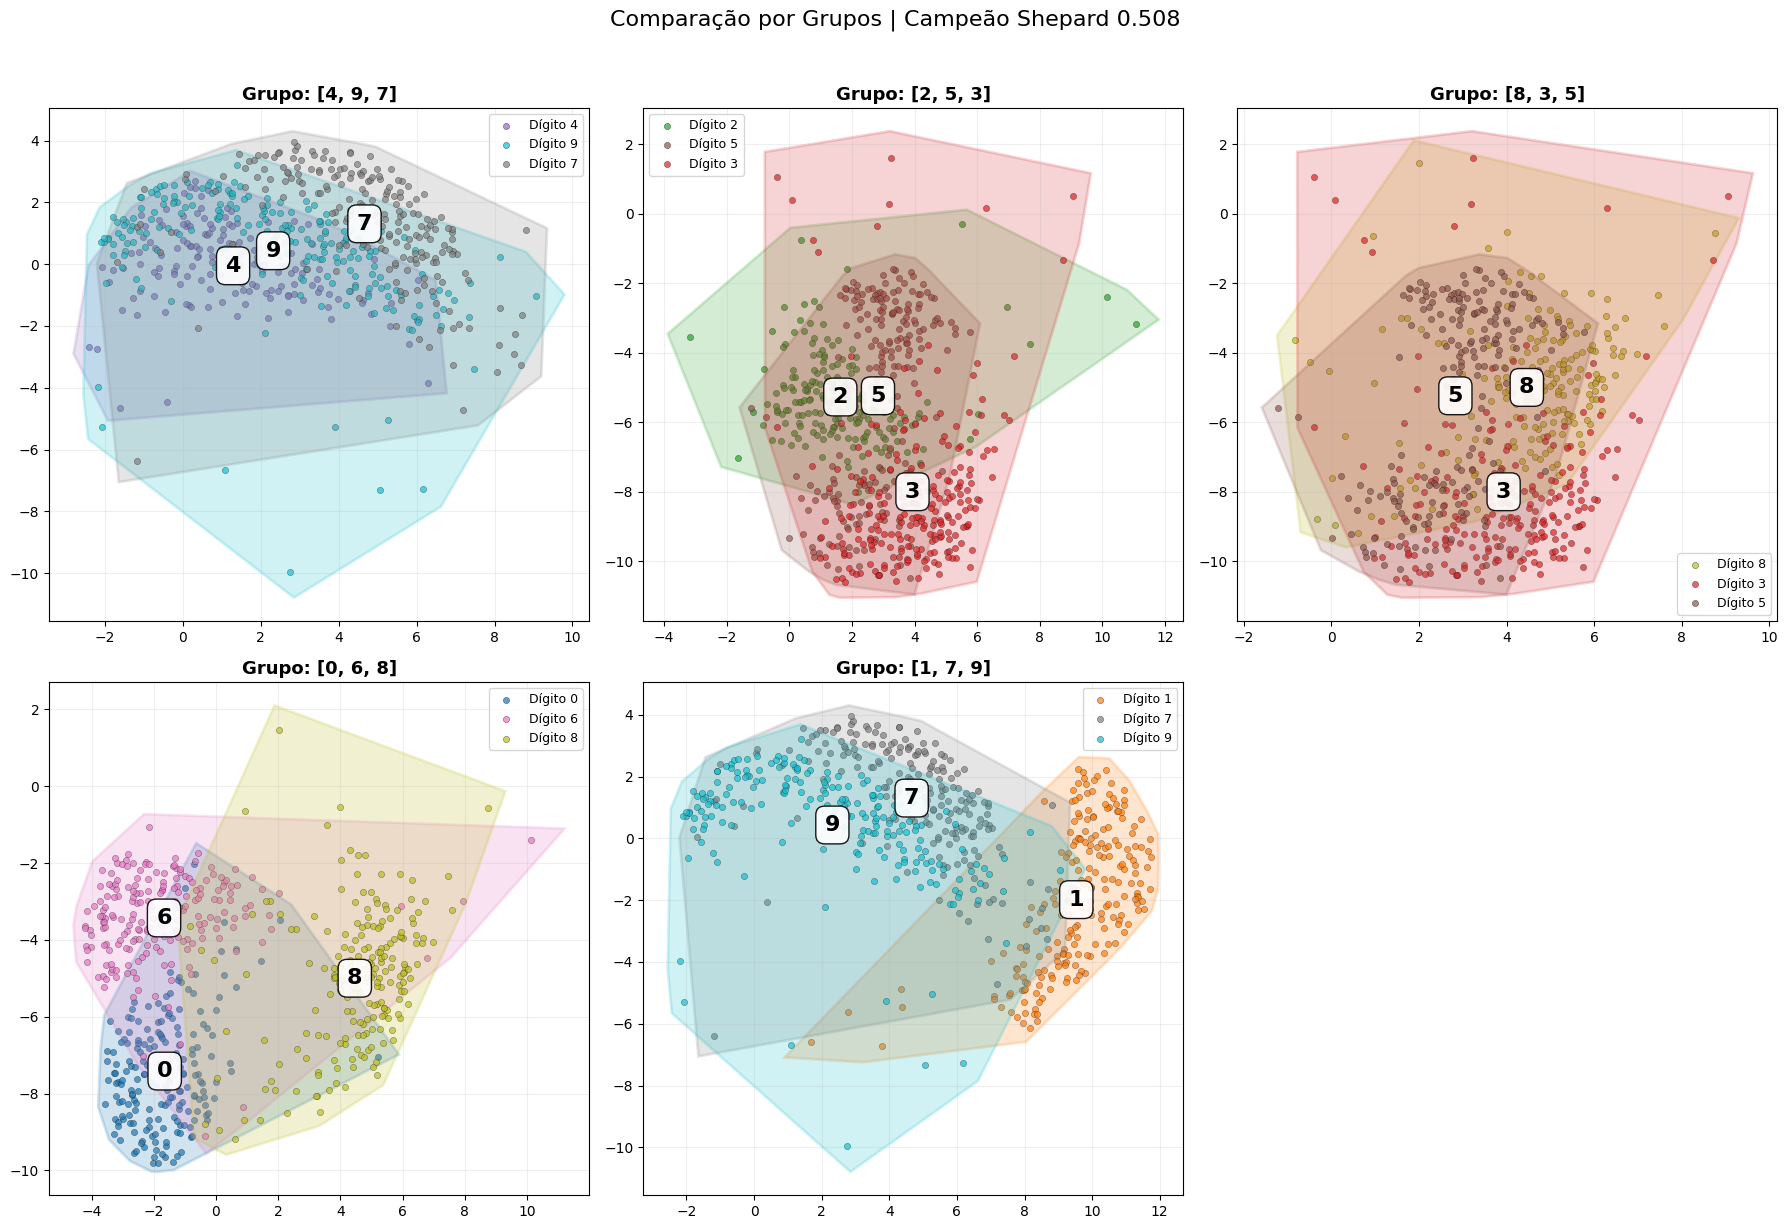

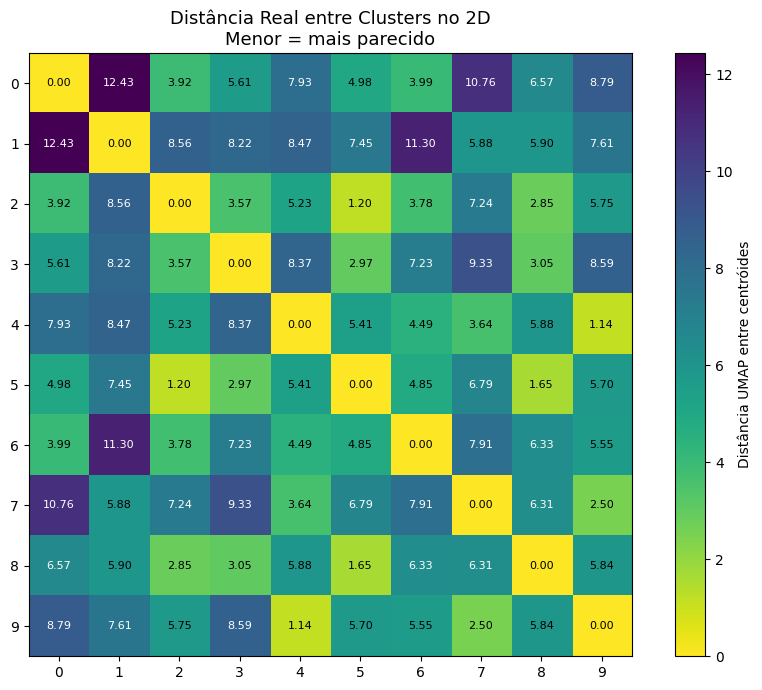

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import trustworthiness
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
import time
from itertools import product
from IPython.display import clear_output

# GPU/CPU
try:
    from cuml.manifold import UMAP as cuUMAP
    GPU_AVAILABLE = True
    print(">>> UMAP GPU")
except ImportError:
    from umap import UMAP
    GPU_AVAILABLE = False
    print(">>> UMAP CPU")

# 1. MNIST Keras
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_full = np.concatenate([X_train, X_test]).astype('float64').reshape(-1, 784)
y_full = np.concatenate([y_train, y_test]).astype('int')

np.random.seed(42)
idx = np.random.choice(X_full.shape[0], 2000, replace=False)
X = X_full[idx]
y = y_full[idx]
X = normalize(X, norm='l2')

# 2. Métricas
def continuity_score(X_orig, X_proj, n_neighbors=15):
    return trustworthiness(X_proj, X_orig, n_neighbors=n_neighbors)

def shepard_correlation(X_orig, X_proj, sample_size=1000):
    n = X_orig.shape[0]
    sample_size = min(sample_size, n)
    sample_idx = np.random.choice(n, sample_size, replace=False)
    dist_orig = pdist(X_orig[sample_idx])
    dist_proj = pdist(X_proj[sample_idx])
    correlation, _ = spearmanr(dist_orig, dist_proj)
    return correlation

# 3. Grid Search UMAP - critério: MAIOR SHEPARD
def gridsearch_umap_shepard(X, y):
    melhor_params = None
    melhor_shepard = -np.inf
    melhor_X_umap = None
    metricas_finais = None

    param_grid = {
        'n_neighbors': [50, 100, 150, 200],
        'min_dist': [0.1, 0.5, 0.8, 1.0],
        'metric': ['cosine', 'euclidean'],
        'spread': [0.5, 1.0, 1.5, 2.0],
    }

    all_params_raw = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]
    # Filter out invalid combinations where min_dist > spread
    all_params = [p for p in all_params_raw if p['min_dist'] <= p['spread']]

    total = len(all_params)
    print(f"Iniciando grid search UMAP... {total} combinações válidas")
    print("Critério: MAIOR SHEPARD")

    if GPU_AVAILABLE:
        pca_init = PCA(n_components=2, random_state=42).fit_transform(X)

    for i, params in enumerate(all_params):
        start_iter = time.time()

        if GPU_AVAILABLE:
            reducer = cuUMAP(n_components=2, n_epochs=500, init=pca_init, random_state=42, **params)
        else:
            reducer = UMAP(n_components=2, n_epochs=500, init='pca', random_state=42, n_jobs=-1, **params)

        X_umap = reducer.fit_transform(X)

        tw = trustworthiness(X, X_umap, n_neighbors=params['n_neighbors'])
        ct = continuity_score(X, X_umap, n_neighbors=params['n_neighbors'])
        sh = shepard_correlation(X, X_umap, sample_size=1000)
        score_composto = 0.25*tw + 0.25*ct + 0.50*sh
        iter_time = time.time() - start_iter

        print(f"[{i+1}/{total}] {params} | SH:{sh:.4f} TW:{tw:.3f} CT:{ct:.3f} | {iter_time:.1f}s")

        if (sh > melhor_shepard) or (sh == melhor_shepard and metricas_finais is not None and tw > metricas_finais[0]):
            melhor_shepard = sh
            melhor_params = params.copy()
            melhor_X_umap = X_umap
            metricas_finais = (tw, ct, sh, score_composto)
            print(f" >>> NOVO MELHOR SHEPARD: {sh:.4f}")

    melhor_params['init'] = 'pca_manual' if GPU_AVAILABLE else 'pca'
    return melhor_params, melhor_X_umap, metricas_finais

# 4. Executa Grid Search
start_time = time.time()
params, projecao, res = gridsearch_umap_shepard(X, y)
duration = time.time() - start_time

clear_output(wait=True)
print(f"\n{'='*70}")
print(f"Grid Search finalizado em {duration:.2f}s")
print(f"Campeão Shepard: {params}")
print(f"Métricas -> TW: {res[0]:.3f}, CT: {res[1]:.3f}, SH: {res[2]:.3f}")
print(f"{'='*70}")

# 5. Plot Geral com Convex Hull
plt.figure(figsize=(14, 10))
cmap = plt.get_cmap('tab10')
scatter = plt.scatter(projecao[:, 0], projecao[:, 1], c=y, cmap=cmap, s=15, alpha=0.7, edgecolors='k', linewidths=0.2)

for digit in np.unique(y):
    mask = (y == digit)
    points = projecao[mask]
    if len(points) < 3: continue
    try:
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]
        center = hull_points.mean(axis=0)
        hull_expanded = center + 1.1 * (hull_points - center)
        poly = Polygon(hull_expanded, alpha=0.12, facecolor=cmap(digit/10), edgecolor=cmap(digit/10), linewidth=2)
        plt.gca().add_patch(poly)
    except: pass
    c_x, c_y = points[:, 0].mean(), points[:, 1].mean()
    plt.text(c_x, c_y, str(digit), fontsize=18, fontweight='bold', ha='center', va='center',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.4'))

plt.title(f"UMAP Todos os Dígitos | SH: {res[2]:.3f} | TW: {res[0]:.3f}\n{params}", fontsize=14)
plt.colorbar(scatter, label='Dígito', ticks=range(10))
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# 6. Subplots com 3 clusters cada
centroids = np.array([projecao[y == d].mean(axis=0) for d in range(10)])
dist_matrix = squareform(pdist(centroids))

grupos = [
    [4, 9, 7], # Traço vertical + curva
    [2, 5, 3], # Curvas abertas
    [8, 3, 5], # Duas barrigas
    [0, 6, 8], # Loops fechados
    [1, 7, 9], # Retas/inclinados
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, grupo in enumerate(grupos):
    if i >= len(axes): break
    ax = axes[i]

    for digit in grupo:
        mask = (y == digit)
        points = projecao[mask]
        ax.scatter(points[:, 0], points[:, 1], c=[cmap(digit/10)], s=20, alpha=0.7,
                   edgecolors='k', linewidths=0.3, label=f'Dígito {digit}')

        if len(points) >= 3:
            try:
                hull = ConvexHull(points)
                hull_points = points[hull.vertices]
                center = hull_points.mean(axis=0)
                hull_expanded = center + 1.1 * (hull_points - center)
                poly = Polygon(hull_expanded, alpha=0.2, facecolor=cmap(digit/10),
                             edgecolor=cmap(digit/10), linewidth=2)
                ax.add_patch(poly)
            except: pass

            c_x, c_y = points[:, 0].mean(), points[:, 1].mean()
            ax.text(c_x, c_y, str(digit), fontsize=16, fontweight='bold', ha='center', va='center',
                   bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.4'))

    ax.set_title(f"Grupo: {grupo}", fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.2)

if len(grupos) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle(f"Comparação por Grupos | Campeão Shepard {res[2]:.3f}", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 7. Heatmap de distância entre centróides
plt.figure(figsize=(9, 7))
plt.imshow(dist_matrix, cmap='viridis_r', interpolation='nearest')
plt.colorbar(label='Distância UMAP entre centróides')
plt.xticks(range(10))
plt.yticks(range(10))
plt.title('Distância Real entre Clusters no 2D\nMenor = mais parecido', fontsize=13)
for i in range(10):
    for j in range(10):
        plt.text(j, i, f'{dist_matrix[i,j]:.2f}', ha='center', va='center',
                color='white' if dist_matrix[i,j] > dist_matrix.max()/2 else 'black', fontsize=8)
plt.tight_layout()
plt.show()